# Lab 1: First Contact with Sentinel-1 over Kraków

This notebook is designed to do four things:

1. initialize the Earth Engine environment,
2. load Sentinel-1 GRD data over Kraków,
3. compare how SAR brightness changes across time,
4. some introductory .

Students should become comfortable with:

- loading satellite data in Python,
- working with an `ee.ImageCollection`,
- computing simple summary products,
- plotting histograms,
- comparing maps through time.

By the end of this notebook, students should be able to:

- explain what a Sentinel-1 image collection is,
- filter the collection to a consistent subset of scenes,
- produce a median monthly image for a given year,
- compare brightness distributions between years,
- compute a simple change metric,
- describe what they think the observed differences might represent.

---

In [5]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import datetime

print("Imports loaded.")

Imports loaded.


## 1. Initialize Google Earth Engine

This notebook assumes the Earth Engine Python API is already installed and authenticated.

If you are running this for the first time on a new machine, you may need to run:

```python
ee.Authenticate()
```

and then initialize with the project ID.

In [6]:
ee.Authenticate()
ee.Initialize(project="effective-tea-494108-k0")
print("Earth Engine initialized OK.")


Successfully saved authorization token.
Earth Engine initialized OK.


## 2. Define the area of interest and some reusable settings

We use a small rectangle around Kraków.

We will work with **Sentinel-1 GRD** scenes that satisfy a consistent set of filters:

- intersect the AOI,
- same month or date range,
- IW mode,
- both VV and VH available,
- ascending orbit,
- 10 m resolution.

Using consistent filtering is important because it reduces differences caused by acquisition geometry rather than real surface change.

**Question (4 pts): Throughout this lab, we will be comparing SAR GRD level data to compare the same AOI over different periods of time. Why is it important to keep the orbit direction consistent when comparing scenes over time?**

**ANSWER:**
*It is critical to keep the orbit direction consistent because SAR is a side-looking sensor. An Ascending orbit (South to North) and a Descending orbit (North to South) view the surface from opposite look-directions. This causes geometric distortions—specifically shadows and layover—to flip positions relative to terrain features and urban infrastructure. If the orbit direction is not consistent, the differences in backscatter between scenes may be attributed to changes in viewing geometry and shadow patterns rather than actual physical changes on the ground, making accurate change detection impossible.*

In [19]:
# Area of interest: Kraków and surrounding urban/peri-urban area
aoi = ee.Geometry.Rectangle([19.867, 50.013, 20.0, 50.077])

# Analysis settings
ORBIT_PASS = "ASCENDING"
MODE = "IW"
RESOLUTION = 10

# Year range used later in the notebook
years = list(range(2015, 2025))

m = geemap.Map()
m.centerObject(aoi, 12)
m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[50.04501188618586, 19.93349999999828], controls=(WidgetControl(options=['position', 'transparent_b…

## 3. Helper functions

These functions do most of the repetitive work:

- `get_s1_collection(...)`: build a filtered Sentinel-1 collection,
- `get_monthly_median(...)`: produce a median image for a given month and year,
- `show_scene_metadata(...)`: inspect dates and metadata,
- `fixed_histogram(...)`: compute a histogram for plotting,
- `region_stats(...)`: compute simple summary statistics over the AOI.

In [31]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass=ORBIT_PASS,
                      mode=MODE,
                      resolution=RESOLUTION):
    """
    Return a filtered Sentinel-1 GRD ImageCollection.
    """
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('instrumentMode', mode))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('orbitProperties_pass', orbit_pass))
        .filter(ee.Filter.eq('resolution_meters', resolution))
    )

    return collection


def get_monthly_median(year, month=8, region=aoi):
    """
    Return the median Sentinel-1 image for a given month and year.
    By default, this is August because it reduces seasonal variation
    and avoids snow-related complications.
    """
    start = f"{year}-{month:02d}-01"
    if month == 12:
        end = f"{year + 1}-01-01"
    else:
        end = f"{year}-{month + 1:02d}-01"

    #YOUR CODE HERE (10 pts). IN SECTION 4, YOU MANUALLY GOT THE COLLECTION AND SET THE MEDIAN.
    #SINCE WE INTEND TO DO THIS MULTIPLE TIMES, LETS PUT THIS IN A FUNCTION
# Use the helper function we just fixed
    collection = get_s1_collection(start, end, region=region)
    
    # Calculate the median
    image = collection.median().clip(region)
    return image.set({
        "year": year,
        "month": month,
        "scene_count": collection.size()
    })


import datetime

def show_scene_metadata(collection):
    """
    Print selected metadata including orbit and slice info to identify 
    why we have duplicate dates.
    """
    # Extract data from the server
    times = collection.aggregate_array("system:time_start").getInfo()
    passes = collection.aggregate_array("orbitProperties_pass").getInfo()
    orbit_nums = collection.aggregate_array("orbitNumber_start").getInfo()
    slice_nums = collection.aggregate_array("sliceNumber").getInfo()
    total_slices = collection.aggregate_array("totalSlices").getInfo()

    # Print Header
    print(f"{'Date':<12} | {'Orbit #':<10} | {'Slice':<8} | {'Total'}")
    print("-" * 45)

    # Loop through and print the rows
    for t, p, orb, s_num, t_slice in zip(times, passes, orbit_nums, slice_nums, total_slices):
        dt = datetime.datetime.utcfromtimestamp(t / 1000)
        # Printing the specific fields required to prove they are the same orbit but different slices
        print(f"{str(dt.date()):<12} | {orb:<10} | {s_num:<8} | {t_slice}")


def fixed_histogram(image, region, band, hist_min, hist_max, n_bins=100, scale=10):
    """
    Compute a fixed histogram for one band of an Earth Engine image.
    Returns bin centers, counts, and bin width.
    """
    hist = image.select(band).reduceRegion(
        reducer=ee.Reducer.fixedHistogram(hist_min, hist_max, n_bins),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    ).get(band)

    hist = ee.List(hist).getInfo()
    bin_edges = [row[0] for row in hist]
    counts = [row[1] for row in hist]
    bin_width = (hist_max - hist_min) / n_bins
    bin_centers = [edge + bin_width / 2 for edge in bin_edges]

    return bin_centers, counts, bin_width


def normalize_counts(counts):
    total = sum(counts)
    if total == 0:
        return counts
    return [c / total for c in counts]


def region_stats(image, region, band):
    """
    Return mean, median, std dev, and max for a selected band.
    """
    stats = image.select(band).reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
        ),
        geometry=region,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {
        "mean": stats.get(f"{band}_mean"),
        "median": stats.get(f"{band}_median"),
        "stdDev": stats.get(f"{band}_stdDev"),
        "max": stats.get(f"{band}_max"),
    }




print("Helper functions defined.")

Helper functions defined.


## 4. Inspect one month of data in detail

This section focuses on January 2024.  
The goal is no deep interpretation yet — it is simply to inspect the collection and compare the returned GRD file, comparing the scene with your a priori knowledge of the Krakow area.

We want to return a filtered Sentinel-11 GRD ImageCollection that is filtered by:
- region
- start_date and end_date
- instrumentMode = "IW"
- transmitterReceiverPolarisation contains both "VV" and "VH"
- orbitProperties_pass = "ASCENDING"
- resolution_meters = 10

Things you might notice:
- For a given AOI, multiple slices can exist,
- one overpass can be represented by multiple scene slices,
- image collections often contain more than one product per date over the AOI.



In [32]:
# Visualization presets
vv_vis = {"min": -20, "max": 0}
vh_vis = {"min": -28, "max": -5}
#YOU WILL NEED TO WRITE THE get_s1_collection FUNCTION TO GET THIS TO WORK. ONCE YOU HAVE
#THE FUNCTION WORKING, PLACE IT IN THE FUNCTIONS CODE BLOCK IN SECTION 3.
jan_2024 = get_s1_collection("2024-01-01", "2024-02-01", region=aoi)

#YOU WILL NEED TO ADAPT THE show_scene_metadata() FUNCTION TO ANSWER THE QUESTION BELOW
print("Image count:", jan_2024.size().getInfo())
show_scene_metadata(jan_2024)

jan_2024_img = jan_2024.median().clip(aoi)

m = geemap.Map()
m.centerObject(aoi, 10)

#If we were plotting just one img, you would simply use the line below. A split_map allows
#two scenes to be compared via a slider bar.
#m.addLayer(jan_2024_img.select("VV"), vv_vis, "VV January 2024")

m.split_map(
    left_layer=geemap.ee_tile_layer(jan_2024_img.select("VV"), vv_vis, "VV January 2024"),
    right_layer=geemap.ee_tile_layer(jan_2024_img.select("VH"), vh_vis, "VH January 2024")
)
display(m)

Image count: 8
Date         | Orbit #    | Slice    | Total
---------------------------------------------
2024-01-05   | 51974      | 13       | 29
2024-01-05   | 51974      | 14       | 29
2024-01-10   | 52047      | 13       | 29
2024-01-17   | 52149      | 13       | 29
2024-01-17   | 52149      | 14       | 29
2024-01-22   | 52222      | 13       | 29
2024-01-29   | 52324      | 13       | 29
2024-01-29   | 52324      | 14       | 29


Map(center=[50.04501188618586, 19.93349999999828], controls=(ZoomControl(options=['position', 'zoom_in_text', …

**QUESTION (4 pts): We know Sentinel-1 has an approximately 6-day repeat time. However, from the metadata presented above, there are 10 images that GEE grabbed, two for each acquisition day. Why is that? Do not guess, look into the metadata for those scenes to get your answer. You will need to modify the metadata function in the helper functions code block above. Please also adjust the print function to print the metadata field you thinks supports your answer**

Some common metadata fields are:`time_start`, `platform_number`, `orbitProperties_pass`, `relativeOrbitNumber_start`, `sliceNumber`, `totalSlices`, `instrumentMode`, `transmitterReceiverPolarisation`, `resolution_meters`, and `orbitNumber_start`. 

**ANSWER:**
Sentinel-1 captures data in very long, continuous strips as it orbits the Earth. Processing these massive strips is computationally difficult, so the European Space Agency (ESA) cuts these long strips into smaller, manageable, and slightly overlapping segments called Slices.

## 5. Compare early and recent August composites

For the first change-oriented comparison, we use one August composite near the beginning and one near the end of the analysis period.

Why August?
- it helps keep the seasonal window consistent,
- it avoids winter snow issues,
- it gives a cleaner year-to-year comparison.

Why not August?
- Vegetative growth may impact radar returns (e.g., depending on the conditions earlier in the summer, foliage may be at a different growth level

> **If you are curious:**  
> Once you have finished the lab, you can change the month from August to January or April (or any of your choice) and describe how the maps, histograms, or time series plots differ. Maybe another month would be a better choice?


In [33]:
# Build one August median image for every year
images_by_year = {year: get_monthly_median(year, month=8, region=aoi) for year in years}

first_year = years[0]
last_year = years[-1]

img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_first.select("VV"), vv_vis, f"VV {first_year}"),
    right_layer=geemap.ee_tile_layer(img_last.select("VV"), vv_vis, f"VV {last_year}")
)
display(m)

Map(center=[50.04501188618586, 19.93349999999828], controls=(ZoomControl(options=['position', 'zoom_in_text', …

**QUESTION (8 pts): Compare the 2015 and 2025 median maps carefully.** 

- Start with the old town. Do you notice much change? Why do you think that is?
- Find an area that has significant change in bright pixels. What does this represent?
- What about the darkest pixels?
- Pixels or groups of pixels that are consistently bright across many years are excellent candidates for 
      the persistent scatterer, which we will cover in a later lab. What features do you think might make 
      excellent candidates for persistent scatterer analysis? 

**ANSWER:**


## 6. Histogram comparison of VV brightness

A histogram is a simple way to summarize the distribution of pixel brightness values over the AOI.

Here we compare the VV histograms for the first and last August composites.

This is useful because a map can be visually overwhelming, while a histogram can show whether:
- the distribution shifts,
- the bright tail changes,
- one year has more bright scatterers than another.

>Important note:
A histogram of the whole AOI is a blunt tool. If the signal is subtle, the result may be hard to interpret. That is okay — part of the lesson is learning that some analyses are more sensitive than others.

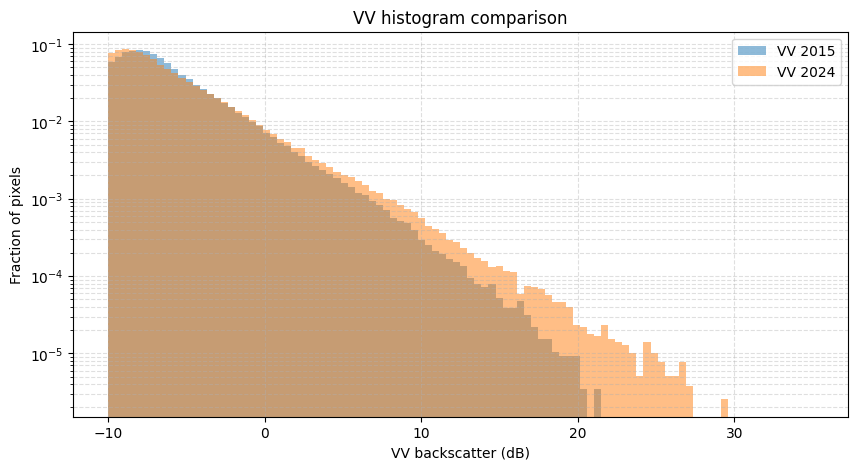

2015 VV stats: {'mean': -7.281152075350492, 'median': -7.625478372240308, 'stdDev': 3.8258102072152855, 'max': 21.153294048488938}
2024 VV stats: {'mean': -7.665555217640409, 'median': -8.125486890314685, 'stdDev': 4.230473827491083, 'max': 29.241419632053507}


In [34]:
# Histogram settings
vv_hist_min = -10
vv_hist_max = 35
vv_hist_bins = 100

x1, y1, bw1 = fixed_histogram(img_first, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)
x2, y2, bw2 = fixed_histogram(img_last, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)

y1n = normalize_counts(y1)
y2n = normalize_counts(y2)

plt.figure(figsize=(10, 5))
plt.bar(x1, y1n, width=bw1, alpha=0.5, label=f"VV {first_year}")
plt.bar(x2, y2n, width=bw2, alpha=0.5, label=f"VV {last_year}")
plt.xlabel("VV backscatter (dB)")
plt.ylabel("Fraction of pixels")
plt.title("VV histogram comparison")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.show()

stats_first = region_stats(img_first, aoi, "VV")
stats_last = region_stats(img_last, aoi, "VV")

print(f"{first_year} VV stats:", stats_first)
print(f"{last_year} VV stats:", stats_last)

**QUESTION (4 pts): What do you notice about the distribution on the bright side tail of the distribution of pixel brightness? Discuss both the number of bright pixels and their distribution, and what each represents. ADJUST THE X-AXIS IN THE CODE TO GRAB THE PART OF THE HISTOGRAM THAT SUPPORTS YOUR ANSWER BELOW**

**ANSWER:**


## 7. Compute a simple SAR ratio image: VV - VH

A very simple and common calculation is the difference between the VV and VH bands:

\[
VV - VH
\]

This is not a full physical interpretation yet, but it is a useful derived quantity because it often separates surface types better than VV or VH alone. We will cover polarimetric SAR in later labs and lectures,
but the important thing to know here is that VV returns most strongly come from hard surface reflectors, things
like buildings, bridges, and roads, while VH returns most strongly come from distributed or volumetric scattering,
for example by bouncing many times in vegetative growth before returning to the satellite.

Here we compare the ratio-like image `VV - VH` for the first and last August composites.

To do this, select the VV band of the first image, subtract the VH band of the first image, then rename the result "VVVH" Then, do the same for the last image. Then, plot this as a split_map centered on the AOI.


In [35]:
###YOUR CODE HERE (16 pts)

**QUESTION (4 pts): Where do you notice the biggest changes in the VV-VH ratio. Focus not only on the largest increases, but also the largest decreases. In doing so, are we making a qualitative or quantitative assesment?**

**ANSWER:**


## 8. Visualize change in VV - VH

Now we map the difference:

\[
(VV - VH)_{last} - (VV - VH)_{first}
\]

Positive values indicate an increase in this quantity through time, while negative values indicate a decrease.

At this stage, you should not over-interpret the result. The correct first step is simply to identify:
- where change appears strongest,
- whether it is spatially clustered,
- whether it seems plausible.



In [36]:
# Visualization presets
change_vis = {"min": -3, "max": 3, "palette": ["blue", "white", "red"]}

ratio_change = ratio_last.subtract(ratio_first).rename("dVVVH")

m2 = geemap.Map()
m2.centerObject(aoi, 11)
m2.addLayer(ratio_change, change_vis, "Change in VV-VH")
display(m2)

NameError: name 'ratio_last' is not defined

**QUESTION (4 pts): Investigate this change map carefully.** 

- First, identify an area that had a large scale increase in this ratio. Why did VV increase relative to VH in this area?
- Second, I want you to find the area in the top right of the map that had a significant decrease in VV/VH. You can use the code block below to highlight where it is. Using optical data (google maps is fine here), tell me what that feature is. Why do you think it may have had strong VV in 2015, and strong VH in 2025, even though they were both taken in August?**

`aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])`

`m2.addLayer(aoi, {"color": "red"}, "AOI")`

**ANSWER:**

## 9. Threshold-based change mask

This section turns a continuous change image into a very simple binary mask.

This is intentionally crude. The point is to show that:
- a threshold is a choice,
- different thresholds produce different maps,
- classification decisions require judgment.

The logic below flags pixels that:
- started relatively low,
- ended relatively high,
- increased by at least a chosen amount.

In [ ]:
low_thresh = 
high_thresh = 
change_thresh = 

#WRITE THE LOGIC TO FLAG PIXELS THAT HAVE SATISFIED THE ABOVE THRESHOLDS. USEFUL LOGIC
#FUNCTIONS INCLUDE .And(), .Or(), .lt() for less than, .gt() for greater than
transition = (
    #YOUR CODE HERE (10 pts)
)

#This block will print your fraction of the AOI that you have flagged
frac = transition.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("transition").getInfo()

print("Fraction flagged:", frac)

m3 = geemap.Map()
m3.centerObject(aoi, 11)
m3.addLayer(img_last.select("VV"), vv_vis, f"VV {last_year}")
m3.addLayer(ratio_change, change_vis, "d(VV-VH)")
m3.addLayer(
    transition.updateMask(transition),
    {"min": 0, "max": 1, "palette": ["yellow"]},
    "Transition mask"
)
display(m3)

**QUESTION (4 pts): Why did you choose the thresholds that you chose? Was it easy, or even possible, to arrive at a classification scheme that you think accurately captured urban development in the Krakow area?**

**ANSWER:**


## 10. Histogram of the change image

This plot summarizes the distribution of the `VV - VH` change image.

It is useful for:
- seeing whether most pixels changed very little,
- checking whether the distribution is centered near zero,
- deciding whether the threshold values are reasonable.

In [ ]:
x_change, y_change, bw_change = fixed_histogram(
    ratio_change, aoi, "dVVVH", hist_min=-20, hist_max=20, n_bins=100
)

y_change_norm = normalize_counts(y_change)

plt.figure(figsize=(10, 5))
plt.bar(x_change, y_change_norm, width=bw_change, alpha=0.7)
plt.xlabel("Change in VV-VH (dB)")
plt.ylabel("Fraction of pixels")
plt.title("Histogram of VV-VH change")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (4 pts):
First, notice that this histogram is not centered on 0, it is shifted slightly towards negative values. This means that VV is stronger in 2015 than in 2025! Does this go against all the analysis you just did? If this is confusing, go back to the very first split_image, comparing VV in 2015 and 2025. When we first did that, we were focused on the brightest pixels only. Now I want you to focus on the map as a whole, ignoring the brightest pixels. What can you say about the strength of VV returns in 2015 vs 2025. Thinking about what we have learned about scattering physics, what do you think might be the cause of this?**

**ANSWER:**


## 11. Track a simple metric through time

Instead of comparing only two years, we can compute the same metric for every year.

Here we calculate the fraction of the AOI with:

\[
VV - VH > threshold
\]

for each August composite.

This is a very simple time-series summary. It is not a full change detection method, but it requires:
- looping over years,
- deriving one metric per image,
- plotting a time series.

In [ ]:
ratio_thresh = 15
rows = []

for year in years:
    yearly = images_by_year[year]
    ratio = yearly.select("VV").subtract(yearly.select("VH")).rename("VVVH")

    frac_flagged = ratio.gt(ratio_thresh).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get("VVVH").getInfo()

    rows.append({
        "year": year,
        "frac_flagged": frac_flagged
    })

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["frac_flagged"], marker="o")
plt.xlabel("Year")
plt.ylabel("Fraction of pixels flagged")
plt.title(f"Fraction of AOI with VV-VH > {ratio_thresh} dB")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (8 pts):**

- **Why did you choose the threshold that you did?**
- **This is our first attempt to actually quantify and track a specific metric of urban development over a longer time period. Do you think the metric you arrived at accurately quantifies the amount of urban development? Or do you think the metric shows overall trends in urban development, but that there may be too many assumptions to accurately quantify this?**
- **What do you think may be happening with the outliers?**

**ANSWER:**
